In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [4]:
telegram_path = Path("data/telegram/telegram_data.csv")
tg_data = pd.read_csv(telegram_path)

tg_data['date'] = pd.to_datetime(tg_data['date'], errors='coerce', utc=True)
tg_data = tg_data.dropna(subset=['date'])
tg_data['date'] = tg_data['date'].dt.tz_convert('Europe/Kiev')

tg_data = tg_data.dropna(subset=['text'])
tg_data = tg_data.drop_duplicates(subset=['text', 'date'])

tg_data['hour'] = tg_data['date'].dt.hour
tg_data['day_of_week'] = tg_data['date'].dt.day_name()
tg_data['month_year'] = tg_data['date'].dt.to_period('M')

print(f"Дані успішно завантажено! Кількість рядків: {tg_data.shape[0]}")

Дані успішно завантажено! Кількість рядків: 357062


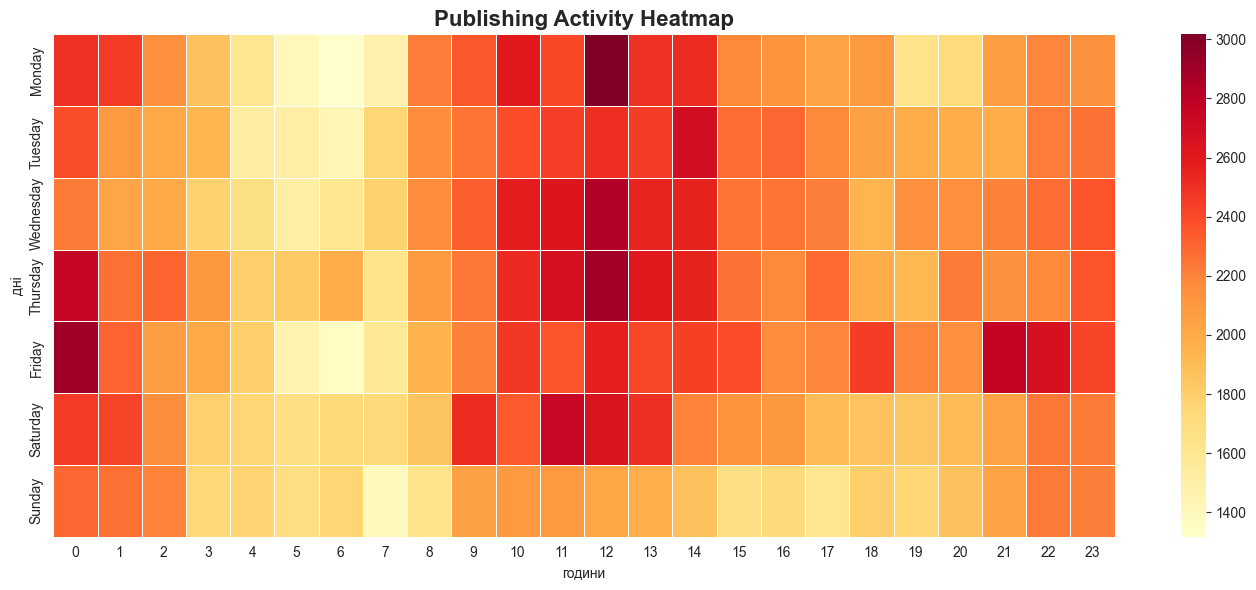

In [5]:
# 2. TIME-BASED ANALYSIS: Publishing Activity Heatmap
# Це покаже, в які дні тижня та години найчастіше пишуть в ТГ
activity_matrix = tg_data.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
activity_matrix = activity_matrix.reindex(days_order)

plt.figure(figsize=(14, 6))
sns.heatmap(activity_matrix, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title("Publishing Activity Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("години")
plt.ylabel("дні")
plt.tight_layout()
plt.show()

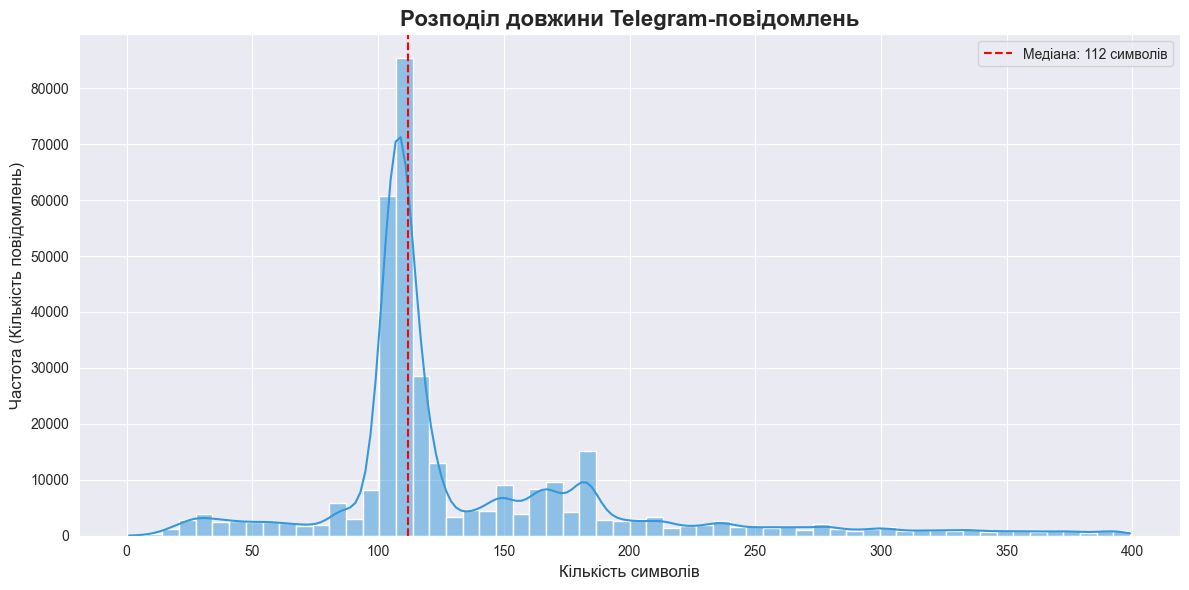

In [6]:
# 3. TEXT STRUCTURE: Article Length Distribution (Idea 11)
tg_data['text_length'] = tg_data['text'].astype(str).apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=tg_data[tg_data['text_length'] < 400], x='text_length', bins=60, color='#3498db', kde=True)

# Додаємо лінію медіани
median_len = tg_data['text_length'].median()
plt.axvline(median_len, color='red', linestyle='--', label=f'Медіана: {median_len:.0f} символів')

plt.title("Розподіл довжини Telegram-повідомлень", fontsize=16, fontweight='bold')
plt.xlabel("Кількість символів", fontsize=12)
plt.ylabel("Частота (Кількість повідомлень)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
stop_words = {
    'і', 'в', 'на', 'з', 'що', 'як', 'до', 'та', 'це', 'за', 'по', 'про', 'від',
    'для', 'а', 'ми', 'вони', 'є', 'чи', 'або', 'але', 'тут', 'там', 'у', # прибрали 'не'
    'и', 'с', 'что', 'как', 'к', 'это', 'о', 'от', 'які', 'який', 'все', 'цього', 'буде', 'вже',
    'слідкуйте', 'подальшими', 'повідомленнями', 'новину', 'надіслати', 'підписатися',
    'зверніть', 'увагу', 'район', 'область', 'територіальна', 'громада', 'м_нікополь_та_нікопольська_територіальна_громада',
    'підписка', 'канал', 'адмін', 'джерело', 'посилання', 'наслідки'
}
def clean_text(text):
    text = str(text).lower() 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) 
    text = re.sub(r'\@\w+|\#', '', text) 
    text = re.sub(r'[^\w\s]', '', text) 
    text = text.replace('_', ' ')
    text = re.sub(r'\d+', '', text) 
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

tg_data['clean_text'] = tg_data['text'].apply(clean_text)

threat_keywords = ['пуск', 'виліт', 'баліст', 'мопед', 'шахед', 'ракет', 'укриття', 'увага', 'зліт', 'міг', 'кінжал']

def has_threat(text):
    for word in threat_keywords:
        if word in str(text):
            return 1
    return 0

tg_data['has_threat_keyword'] = tg_data['clean_text'].apply(has_threat)

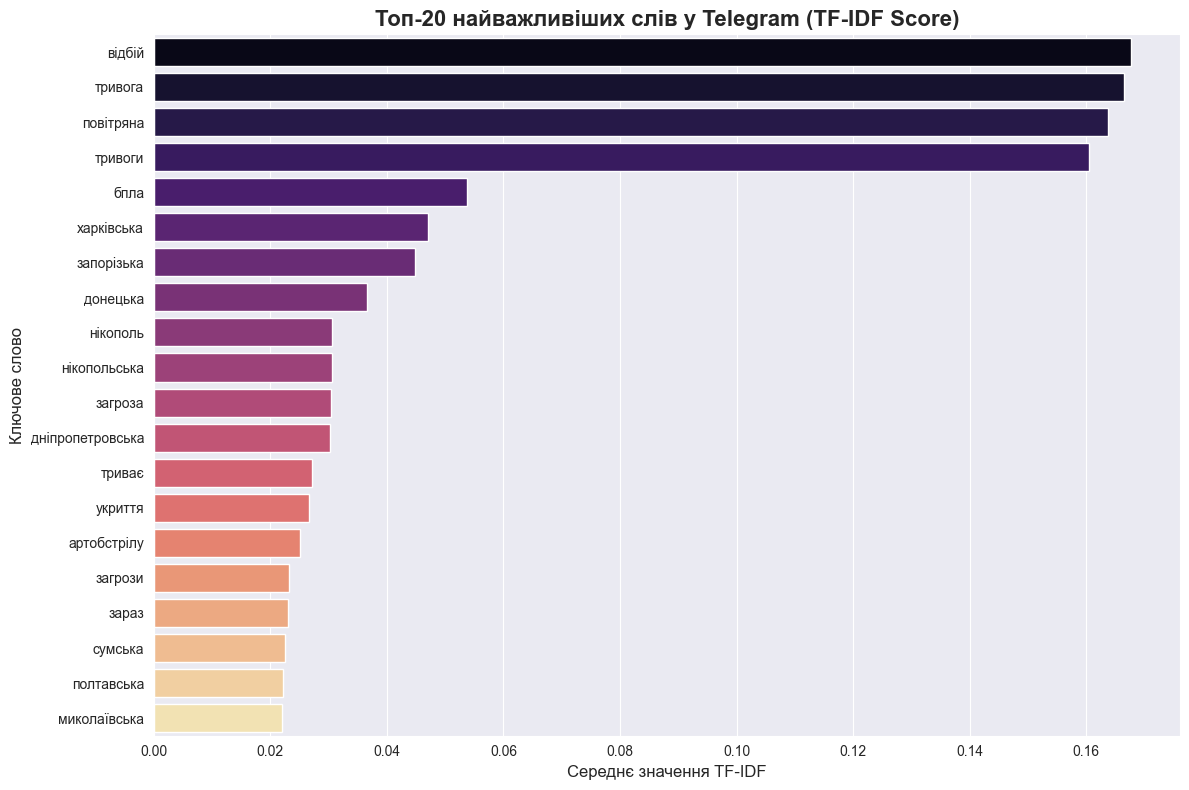

In [11]:
# 5. TEXT CONTENT ANALYSIS: TF-IDF Top Keywords (Idea 6)
sample_texts = tg_data['clean_text'].tail(400000).dropna()

tfidf = TfidfVectorizer(max_features=20)
tfidf_matrix = tfidf.fit_transform(sample_texts)

# Рахуємо вагу кожного слова
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
words = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame({'Word': words, 'TF-IDF Score': mean_tfidf}).sort_values(by='TF-IDF Score', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='TF-IDF Score', y='Word', data=tfidf_df, palette='magma')
plt.title("Топ-20 найважливіших слів у Telegram (TF-IDF Score)", fontsize=16, fontweight='bold')
plt.xlabel("Середнє значення TF-IDF", fontsize=12)
plt.ylabel("Ключове слово", fontsize=12)
plt.tight_layout()
plt.show()

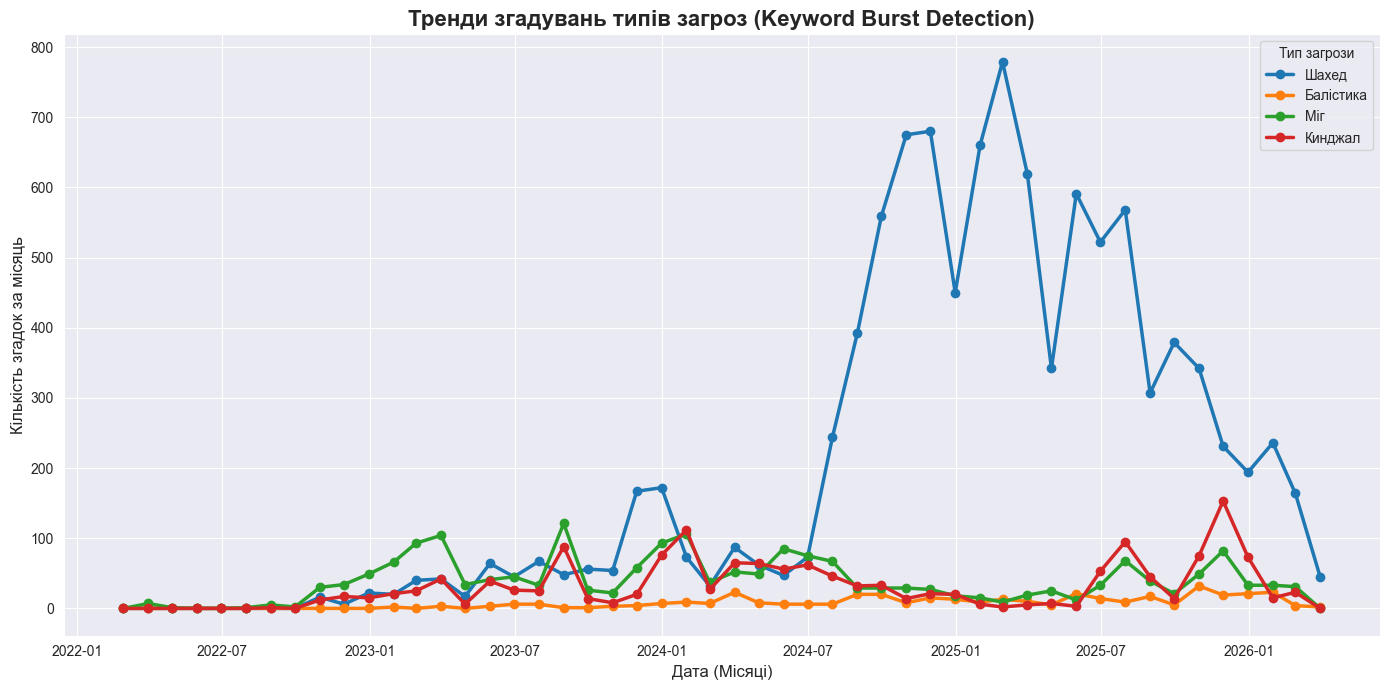

In [12]:
##%%
# 6. LANGUAGE TRENDS & EVENT BURSTS (Idea 13 & 20)
# Відслідковуємо, як часто згадувалися певні загрози з плином часу

target_words = ['шахед', 'балістика', 'міг', 'кинджал']

for word in target_words:
    tg_data[word] = tg_data['clean_text'].apply(lambda x: 1 if word in str(x) else 0)

trends_df = tg_data.set_index('date')[target_words].resample('ME').sum()

plt.figure(figsize=(14, 7))
for word in target_words:
    plt.plot(trends_df.index, trends_df[word], linewidth=2.5, marker='o', label=word.capitalize())

plt.title("Тренди згадувань типів загроз (Keyword Burst Detection)", fontsize=16, fontweight='bold')
plt.xlabel("Дата (Місяці)", fontsize=12)
plt.ylabel("Кількість згадок за місяць", fontsize=12)
plt.legend(title="Тип загрози")
plt.tight_layout()
plt.show()

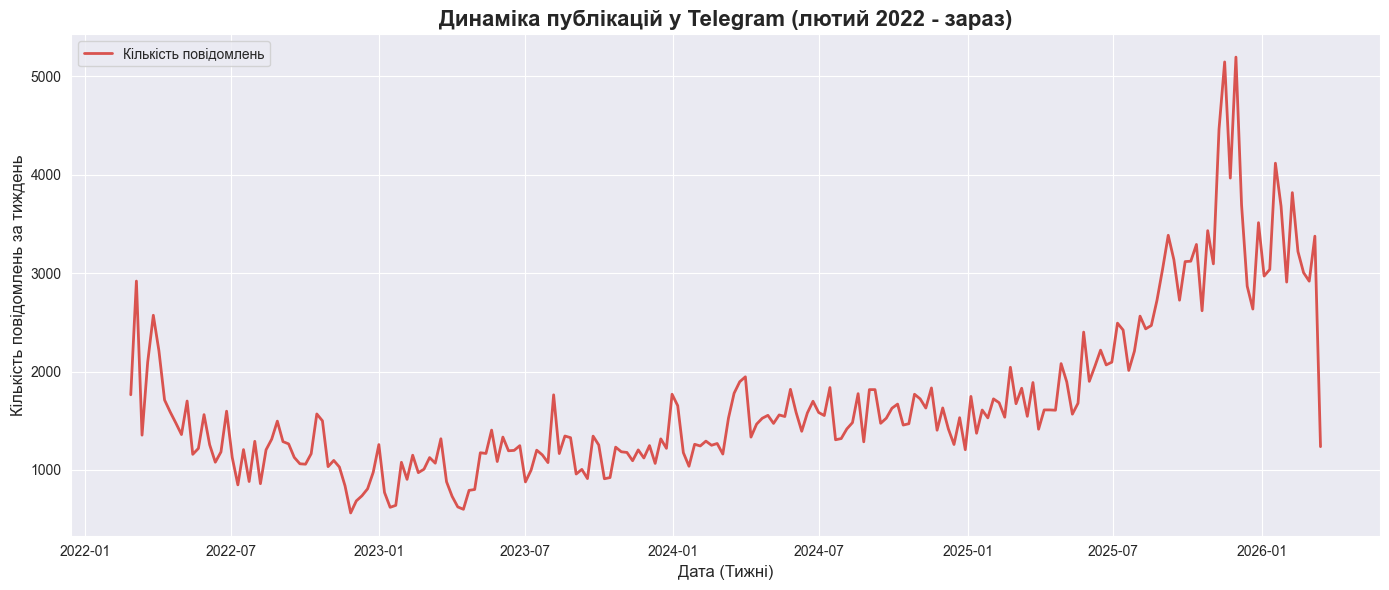

In [13]:
# 2. EDA: ДИНАМІКА ПОВІДОМЛЕНЬ (TIME SERIES)
weekly_counts = tg_data.resample('W', on='date').size()

plt.figure(figsize=(14, 6))
plt.plot(weekly_counts.index, weekly_counts.values, color='#d9534f', linewidth=2, label='Кількість повідомлень')
plt.title("Динаміка публікацій у Telegram (лютий 2022 - зараз)", fontsize=16, fontweight='bold')
plt.xlabel("Дата (Тижні)", fontsize=12)
plt.ylabel("Кількість повідомлень за тиждень", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# 1. ПІДГОТОВКА ЧАСУ (Безпечно від переведення годинників)
tg_data['date'] = pd.to_datetime(tg_data['date'], utc=True)

tg_data['hour_rounded'] = tg_data['date'].dt.floor('h').dt.tz_convert('Europe/Kiev')
tg_data['date'] = tg_data['date'].dt.tz_convert('Europe/Kiev')

In [15]:
# 2. АГРЕГАЦІЯ ТЕКСТІВ ТА СТАТИСТИКИ ПО ГОДИНАХ
hourly_tg = tg_data.groupby('hour_rounded').agg(
    messages_count=('text','count'),
    has_threat_sum=('has_threat_keyword','sum'),
    combined_text=('clean_text', lambda x:' '.join(x))
).reset_index()

full_range = pd.date_range(
    start=hourly_tg['hour_rounded'].min(),
    end=hourly_tg['hour_rounded'].max(),
    freq='h'
)

hourly_tg = (
    hourly_tg
    .set_index('hour_rounded')
    .reindex(full_range)
    .fillna({'messages_count':0,'has_threat_sum':0,'combined_text':''})
    .reset_index()
    .rename(columns={'index':'datetime'})
)

print(f"Отримано {hourly_tg.shape[0]} безперервних годин.")
display(hourly_tg.head(3))

Отримано 35441 безперервних годин.


,datetime,messages_count,has_threat_sum,combined_text
0,2022-02-24 02:00:00+02:00,1.0,0.0,совбез оон проведёт экстренное заседание украи...
1,2022-02-24 03:00:00+02:00,0.0,0.0,
2,2022-02-24 04:00:00+02:00,1.0,0.0,путин прямо сейчас заявил начале проведения сп...


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# 3. NLP ФІЧІ (CountVectorizer)
# Беремо топ-15 найважливіших слів (або біграм)
vectorizer = CountVectorizer(max_features=15, ngram_range=(1,2))
text_vectors = vectorizer.fit_transform(hourly_tg['combined_text'])

cols = [f"nlp_{w.replace(' ','_')}" for w in vectorizer.get_feature_names_out()]
nlp_df = pd.DataFrame(text_vectors.toarray(), columns=cols)

hourly_tg = pd.concat([hourly_tg, nlp_df], axis=1)
hourly_tg = hourly_tg.drop(columns=['combined_text'])

In [14]:
# 4. FEATURE ENGINEERING
hourly_tg['msg_count_last_3h'] = hourly_tg['messages_count'].rolling(3, min_periods=1).sum()
hourly_tg['msg_count_last_24h'] = hourly_tg['messages_count'].rolling(24, min_periods=1).sum()

hourly_tg['threat_diff_1h'] = hourly_tg['has_threat_sum'].diff().fillna(0)

hourly_tg['hour_of_day'] = hourly_tg['datetime'].dt.hour
hourly_tg['day_of_week'] = hourly_tg['datetime'].dt.dayofweek
hourly_tg['is_weekend'] = (hourly_tg['day_of_week'] >= 5).astype(int)

hourly_tg = hourly_tg.fillna(0)

In [15]:
# 5. ПЕРЕВІРКА ТА ЗБЕРЕЖЕННЯ
from pathlib import Path

display(hourly_tg.sample(5))

prepared_path = Path("data/telegram/telegram_hourly_features.csv")
prepared_path.parent.mkdir(parents=True, exist_ok=True) 

hourly_tg.to_csv(prepared_path, index=False)

,datetime,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend
11746,2023-06-28 13:00:00+03:00,5.0,0.0,1,0,2,1,0,0,0,2,2,2,1,1,1,1,0,12.0,138.0,-3.0,13,2,0
4822,2022-09-13 01:00:00+03:00,12.0,0.0,0,0,5,5,4,0,0,0,0,0,6,6,8,5,0,14.0,118.0,-1.0,1,1,0
23632,2024-11-04 18:00:00+02:00,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,169.0,0.0,18,0,0
20164,2024-06-13 07:00:00+03:00,8.0,0.0,4,0,7,3,2,2,2,3,3,3,0,0,1,3,0,13.0,155.0,0.0,7,3,0
15496,2023-12-01 18:00:00+02:00,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.0,190.0,0.0,18,4,0
